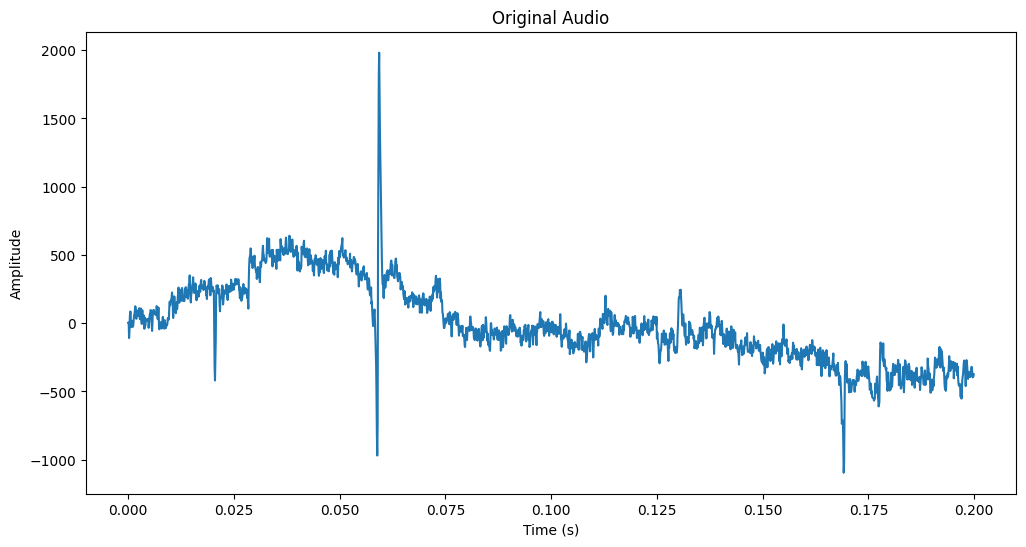

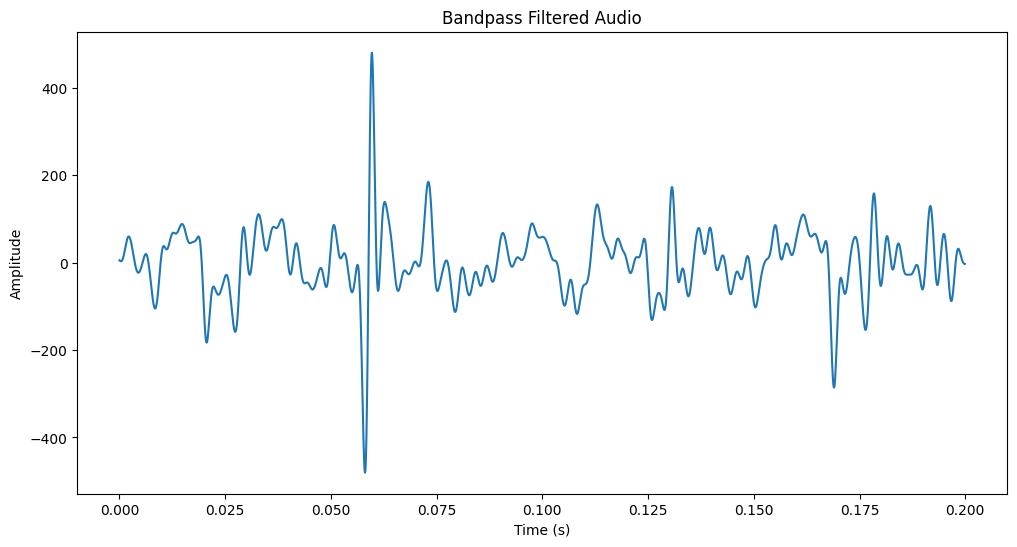

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import butter, filtfilt

def butter_bandpass(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

def apply_bandpass(signal, lowcut, highcut, fs, order=4):
    b, a = butter_bandpass(lowcut, highcut, fs, order)
    return filtfilt(b, a, signal)

# ---- PARAMETERS ----
audio_path = "./data/Spontanaktivität/filtered_BA0803901_segment_1.wav"
lowcut = 20      # Hz
highcut = 400   # Hz
seconds_to_plot = 0.2

# ---- LOAD AUDIO ----
fs, audio = wavfile.read(audio_path)
audio = audio.astype(float)

# Convert to mono if stereo
if audio.ndim > 1:
    audio = audio.mean(axis=1)

# ---- CROP AUDIO ----
num_samples = int(seconds_to_plot * fs)
audio_crop = audio[:num_samples]
time = np.arange(num_samples) / fs

# ---- FILTER ----
filtered_audio = apply_bandpass(audio_crop, lowcut, highcut, fs)

plt.figure(figsize=(12, 4))  # wider plot
plt.plot(time, audio_crop)
plt.title("Original Audio")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

plt.figure(figsize=(12, 4))  # wider plot
plt.plot(time, filtered_audio)
plt.title("Bandpass Filtered Audio")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()
